In [1]:
import os
import tensorflow as tf
from tensorflow.keras.layers import Layer, GlobalAveragePooling2D, Dense, Reshape, Multiply
import joblib
import pandas as pd

class ChannelAttention(Layer):
    """Custom Channel Attention Module"""
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap = GlobalAveragePooling2D()
        self.dense1 = Dense(max(1, channels // self.ratio), activation='relu')
        self.dense2 = Dense(channels, activation='sigmoid')
        self.reshape = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        # Fix missing dimension issue if needed, reshape directly creates 1x1xC shape
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config

def format_size(size_bytes):
    if size_bytes < 1024:
        return f"{size_bytes} B"
    elif size_bytes < 1024 * 1024:
        return f"{size_bytes / 1024:.2f} KB"
    else:
        return f"{size_bytes / (1024 * 1024):.2f} MB"

model_dir = "saved_models_20260421_113929"
loaded_models = {}

print(f"Loading models from {model_dir}...\n")

main_models = ["cnn_attention_model.h5", "feature_extractor.h5", "svm_classifier.pkl"]
model_info = []
additional_files_info = []
total_bytes = 0

for filename in os.listdir(model_dir):
    filepath = os.path.join(model_dir, filename)
    if not os.path.isfile(filepath):
        continue
        
    size_bytes = os.path.getsize(filepath)
    size_str = format_size(size_bytes)
    
    status = "Loaded"
    try:
        if filename.endswith(".h5"):
            loaded_models[filename] = tf.keras.models.load_model(
                filepath, 
                custom_objects={'ChannelAttention': ChannelAttention}
            )
        elif filename.endswith(".pkl"):
            loaded_models[filename] = joblib.load(filepath)
        else:
            status = "Ignored"  # File JSON atau TXT tidak perlu diload sebagai model
    except Exception as e:
        status = f"Error"

    if filename in main_models:
        model_info.append({
            "Nama File": filename,
            "Ukuran": size_str,
            "Ukuran (Bytes)": size_bytes,
            "Load Status": status
        })
        total_bytes += size_bytes
    else:
        desc = "untuk preprocessing" if "scaler" in filename else "dokumentasi training" if "history" in filename else "informasi model"
        # Tambahkan status load jika itu file .pkl
        load_tag = f" [Status: {status}]" if filename.endswith(".pkl") else ""
        additional_files_info.append(f"  • {filename} ({size_str}) - {desc}{load_tag}")

print("TABEL UKURAN MODEL SAAT DI-LOAD:")
print(f"{'Nama File':>25} {'Ukuran':>10} {'Ukuran (Bytes)':>15} {'Load Status':>15}")
for item in model_info:
    print(f"{item['Nama File']:>25} {item['Ukuran']:>10} {item['Ukuran (Bytes)']:>15} {item['Load Status']:>15}")
print(f"{'═══ TOTAL MODEL ═══':>25} {format_size(total_bytes):>10} {total_bytes:>15}")

print("\n================================================================================")
print("Catatan: Ukuran di atas hanya mencakup file model produksi.")
print("File tambahan yang juga tersimpan:")
for info in sorted(additional_files_info):
    print(info)

Loading models from saved_models_20260421_113929...

TABEL UKURAN MODEL SAAT DI-LOAD:
                Nama File     Ukuran  Ukuran (Bytes)     Load Status
   cnn_attention_model.h5   37.29 MB        39104152          Loaded
     feature_extractor.h5   12.44 MB        13044800          Loaded
       svm_classifier.pkl    8.78 KB            8995          Loaded
      ═══ TOTAL MODEL ═══   49.74 MB        52157947

Catatan: Ukuran di atas hanya mencakup file model produksi.
File tambahan yang juga tersimpan:
  • feature_scaler.pkl (999 B) - untuk preprocessing [Status: Loaded]
  • model_info.txt (986 B) - informasi model
  • training_history.json (2.05 KB) - dokumentasi training


In [7]:
import time
import gzip
import shutil
import numpy as np
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import os
import pandas as pd
import joblib

# Deteksi tfmot
try:
    import tensorflow_model_optimization as tfmot
    _TFMOT_AVAILABLE = True
except ImportError:
    _TFMOT_AVAILABLE = False

# ===========================================================================
# PART B: PRUNING HELPERS
# ===========================================================================
def _gzip_file(src_path, dst_path):
    with open(src_path, 'rb') as f_in, gzip.open(dst_path, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

def _build_pruning_masks(weight_list, target_sparsity=0.80):
    masks = []
    for w in weight_list:
        if w.ndim >= 2:
            abs_flat = np.abs(w).flatten()
            if abs_flat.size == 0:
                masks.append(np.ones_like(w, dtype=np.float32))
                continue
            threshold = np.percentile(abs_flat, target_sparsity * 100.0)
            mask = (np.abs(w) >= threshold).astype(np.float32)
            masks.append(mask)
        else:
            masks.append(np.ones_like(w, dtype=np.float32))
    return masks

def _apply_masks(weight_list, masks):
    return [w * m for w, m in zip(weight_list, masks)]

class SparsityMaskCallback(tf.keras.callbacks.Callback):
    def __init__(self, masks):
        super().__init__()
        self.masks = masks

    def on_train_batch_end(self, batch, logs=None):
        weights = self.model.get_weights()
        self.model.set_weights(_apply_masks(weights, self.masks))

def _create_pruned_model(model, final_sparsity, prune_epochs, batch_size, X_train):
    if _TFMOT_AVAILABLE:
        try:
            end_step = int(np.ceil(len(X_train) / batch_size) * prune_epochs)
            schedule = tfmot.sparsity.keras.PolynomialDecay(
                initial_sparsity=0.30,
                final_sparsity=final_sparsity,
                begin_step=0,
                end_step=max(1, end_step),
            )
            pruned_model = tfmot.sparsity.keras.prune_low_magnitude(
                model,
                pruning_schedule=schedule,
            )
            callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]
            return pruned_model, callbacks, "tfmot"
        except Exception as e:
            print(f"[Pruning] tfmot fallback aktif karena: {e}")

    # Fallback manual masking
    pruned_model = tf.keras.models.clone_model(model)
    pruned_model.build(model.input_shape)
    pruned_model.set_weights(model.get_weights())

    masks = _build_pruning_masks(pruned_model.get_weights(), target_sparsity=final_sparsity)
    pruned_model.set_weights(_apply_masks(pruned_model.get_weights(), masks))
    callbacks = [SparsityMaskCallback(masks)]
    return pruned_model, callbacks, "manual-mask"

def setup_pruning_pipeline(model, X_train, X_valid, y_train, y_valid,
                           batch_size=32, prune_epochs=5, final_sparsity=0.80):
    os.makedirs("artifacts", exist_ok=True)

    extractor_orig = Model(
        inputs=model.input,
        outputs=model.get_layer('feature_layer').output,
    )

    # Stage 1
    cnn_keras_path = "artifacts/cnn_attention_model.keras"
    ext_keras_path = "artifacts/cnn_attention_extractor.keras"
    model.save(cnn_keras_path)
    extractor_orig.save(ext_keras_path)
    print(f"[Pruning] Original CNN saved -> {cnn_keras_path}")
    print(f"[Pruning] Original extractor saved -> {ext_keras_path}")

    # Stage 2
    pruned_model, prune_callbacks, prune_mode = _create_pruned_model(
        model=model,
        final_sparsity=final_sparsity,
        prune_epochs=prune_epochs,
        batch_size=batch_size,
        X_train=X_train,
    )

    pruned_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print(f"[Pruning] Fine-tuning mode: {prune_mode}")
    t0 = time.time()
    history_prune = pruned_model.fit(
        X_train, y_train,
        epochs=prune_epochs,
        batch_size=batch_size,
        validation_data=(X_valid, y_valid),
        callbacks=prune_callbacks + [EarlyStopping(patience=2, restore_best_weights=True, monitor='val_loss')],
        verbose=1,
    )
    pruning_finetune_time = time.time() - t0
    print(f"[Pruning] Fine-tune time: {pruning_finetune_time:.3f} s")

    if _TFMOT_AVAILABLE and prune_mode == "tfmot":
        stripped_model = tfmot.sparsity.keras.strip_pruning(pruned_model)
    else:
        stripped_model = pruned_model

    stripped_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    extractor_pruned = Model(
        inputs=stripped_model.input,
        outputs=stripped_model.get_layer('feature_layer').output,
    )

    cnn_pruned_path = "artifacts/cnn_attention_pruned.keras"
    ext_pruned_path = "artifacts/cnn_attention_extractor_pruned.keras"
    stripped_model.save(cnn_pruned_path)
    extractor_pruned.save(ext_pruned_path)

    cnn_pruned_gz_path = "artifacts/cnn_attention_pruned.keras.gz"
    ext_pruned_gz_path = "artifacts/cnn_attention_extractor_pruned.keras.gz"
    _gzip_file(cnn_pruned_path, cnn_pruned_gz_path)
    _gzip_file(ext_pruned_path, ext_pruned_gz_path)

    artifact_paths = {
        'cnn_keras': cnn_keras_path,
        'extractor_keras': ext_keras_path,
        'cnn_pruned': cnn_pruned_path,
        'extractor_pruned': ext_pruned_path,
        'cnn_pruned_gz': cnn_pruned_gz_path,
        'extractor_pruned_gz': ext_pruned_gz_path,
    }

    return artifact_paths, stripped_model, extractor_pruned, history_prune, pruning_finetune_time

def extract_features_keras(extractor_model, X):
    return extractor_model.predict(X, verbose=0)

def _file_size_kb(path):
    return os.path.getsize(path) / 1024.0 if os.path.exists(path) else 0.0

def build_size_table(artifact_paths, svm_orig_path, scaler_orig_path, svm_pruned_path, scaler_pruned_path, orig_sizes=None):
    rows = [
        {
            'Komponen': 'CNN Attention (main)',
            'Awal (KB)': orig_sizes['cnn'] if orig_sizes else _file_size_kb(artifact_paths['cnn_keras']),
            'Setelah Pruning (KB)': _file_size_kb(artifact_paths['cnn_pruned']),
            'Setelah Pruning + GZIP (KB)': _file_size_kb(artifact_paths['cnn_pruned_gz']),
        },
        {
            'Komponen': 'CNN Feature Extractor',
            'Awal (KB)': orig_sizes['extractor'] if orig_sizes else _file_size_kb(artifact_paths['extractor_keras']),
            'Setelah Pruning (KB)': _file_size_kb(artifact_paths['extractor_pruned']),
            'Setelah Pruning + GZIP (KB)': _file_size_kb(artifact_paths['extractor_pruned_gz']),
        },
        {
            'Komponen': 'SVM Classifier',
            'Awal (KB)': orig_sizes['svm'] if orig_sizes else _file_size_kb(svm_orig_path),
            'Setelah Pruning (KB)': _file_size_kb(svm_pruned_path),
            'Setelah Pruning + GZIP (KB)': _file_size_kb(svm_pruned_path),
        },
        {
            'Komponen': 'Feature Scaler',
            'Awal (KB)': orig_sizes['scaler'] if orig_sizes else _file_size_kb(scaler_orig_path),
            'Setelah Pruning (KB)': _file_size_kb(scaler_pruned_path),
            'Setelah Pruning + GZIP (KB)': _file_size_kb(scaler_pruned_path),
        },
    ]
    df = pd.DataFrame(rows)
    total_row = {
        'Komponen': 'TOTAL',
        'Awal (KB)': df['Awal (KB)'].sum(),
        'Setelah Pruning (KB)': df['Setelah Pruning (KB)'].sum(),
        'Setelah Pruning + GZIP (KB)': df['Setelah Pruning + GZIP (KB)'].sum(),
    }
    return pd.concat([df, pd.DataFrame([total_row])], ignore_index=True)

def print_size_table(size_df):
    print("\n" + "=" * 105)
    print("TABEL UKURAN MODEL / ARTEFAK")
    print("=" * 105)
    with pd.option_context('display.max_colwidth', None, 'display.float_format', '{:,.2f}'.format):
        print(size_df.to_string(index=False))
    print("=" * 105)

# ===========================================================================
# PART C: PIPELINE EXECUTION
# ===========================================================================
def run_complete_pipeline(model, X_train, X_valid, X_test,
                         y_train, y_valid, y_test):
    y_train_int = np.argmax(y_train, axis=1)
    y_valid_int = np.argmax(y_valid, axis=1)
    y_test_int = np.argmax(y_test, axis=1)

    artifact_paths, pruned_model, extractor_pruned, history_prune, pruning_finetune_time = setup_pruning_pipeline(
        model, X_train, X_valid, y_train, y_valid
    )

    size_orig_kb = _file_size_kb(artifact_paths['cnn_keras'])

    extractor_orig = Model(inputs=model.input, outputs=model.get_layer('feature_layer').output)
    t0 = time.time()
    X_train_feat_orig = extract_features_keras(extractor_orig, X_train)
    X_val_feat_orig = extract_features_keras(extractor_orig, X_valid)
    X_test_feat_orig = extract_features_keras(extractor_orig, X_test)
    t_feat_orig = time.time() - t0

    scaler_orig = StandardScaler()
    X_train_scaled_orig = scaler_orig.fit_transform(X_train_feat_orig)
    X_val_scaled_orig = scaler_orig.transform(X_val_feat_orig)
    X_test_scaled_orig = scaler_orig.transform(X_test_feat_orig)

    X_svm_train_orig = np.vstack([X_train_scaled_orig, X_val_scaled_orig])
    y_svm_train_orig = np.concatenate([y_train_int, y_valid_int])

    t0 = time.time()
    svm_orig = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    svm_orig.fit(X_svm_train_orig, y_svm_train_orig)
    t_svm_orig = time.time() - t0

    t0 = time.time()
    y_pred_orig = svm_orig.predict(X_test_scaled_orig)
    y_proba_orig = svm_orig.predict_proba(X_test_scaled_orig)
    t_inf_orig = time.time() - t0

    acc_orig = accuracy_score(y_test_int, y_pred_orig)

    print("\n" + "=" * 70)
    print("PIPELINE B: PRUNED MODEL")
    print("=" * 70)

    size_pruned_kb = _file_size_kb(artifact_paths['cnn_pruned'])
    size_pruned_gz_kb = _file_size_kb(artifact_paths['cnn_pruned_gz'])

    t0 = time.time()
    X_train_feat_pruned = extract_features_keras(extractor_pruned, X_train)
    X_val_feat_pruned = extract_features_keras(extractor_pruned, X_valid)
    X_test_feat_pruned = extract_features_keras(extractor_pruned, X_test)
    t_feat_pruned = time.time() - t0

    scaler_pruned = StandardScaler()
    X_train_scaled_pruned = scaler_pruned.fit_transform(X_train_feat_pruned)
    X_val_scaled_pruned = scaler_pruned.transform(X_val_feat_pruned)
    X_test_scaled_pruned = scaler_pruned.transform(X_test_feat_pruned)

    X_svm_train_pruned = np.vstack([X_train_scaled_pruned, X_val_scaled_pruned])
    y_svm_train_pruned = np.concatenate([y_train_int, y_valid_int])

    t0 = time.time()
    svm_pruned = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    svm_pruned.fit(X_svm_train_pruned, y_svm_train_pruned)
    t_svm_pruned = time.time() - t0

    t0 = time.time()
    y_pred_pruned = svm_pruned.predict(X_test_scaled_pruned)
    y_proba_pruned = svm_pruned.predict_proba(X_test_scaled_pruned)
    t_inf_pruned = time.time() - t0

    acc_pruned = accuracy_score(y_test_int, y_pred_pruned)
    print(f"Model size (pruned .keras): {size_pruned_kb:.1f} KB")
    print(f"Model size (pruned .keras.gz): {size_pruned_gz_kb:.1f} KB")
    print(f"Feature extraction time: {t_feat_pruned:.3f} s")
    print(f"SVM training time: {t_svm_pruned:.3f} s")
    print(f"Inference time: {t_inf_pruned:.4f} s")
    print(f"Test accuracy: {acc_pruned:.4f}")

    os.makedirs("artifacts", exist_ok=True)
    svm_orig_path = "artifacts/svm_original.pkl"
    scaler_orig_path = "artifacts/scaler_original.pkl"
    svm_pruned_path = "artifacts/svm_pruned.pkl"
    scaler_pruned_path = "artifacts/scaler_pruned.pkl"

    joblib.dump(svm_orig, svm_orig_path)
    joblib.dump(scaler_orig, scaler_orig_path)
    joblib.dump(svm_pruned, svm_pruned_path)
    joblib.dump(scaler_pruned, scaler_pruned_path)

    # Hardcoded original training sizes from training.ipynb
    orig_sizes = {
        'cnn': 38187.68,
        'extractor': 12739.02,
        'svm': 8.94,
        'scaler': 0.98,
    }

    size_df = build_size_table(
        artifact_paths,
        svm_orig_path,
        scaler_orig_path,
        svm_pruned_path,
        scaler_pruned_path,
        orig_sizes=orig_sizes,
    )

    metrics = {
        'size_kb': [size_orig_kb, size_pruned_gz_kb],
        'size_pruned_raw_kb': [size_orig_kb, size_pruned_kb],
        't_feature': [t_feat_orig, t_feat_pruned],
        't_svm': [t_svm_orig, t_svm_pruned],
        't_infer': [t_inf_orig, t_inf_pruned],
        'accuracy': [acc_orig, acc_pruned],
        'pruning_finetune_time': pruning_finetune_time,
    }

    eval_data = (y_test_int, y_pred_orig, y_pred_pruned, y_proba_orig, y_proba_pruned)

    # Keep old variable names for compatibility with evaluation cells.
    globals()['y_test_int'] = y_test_int
    globals()['y_pred_orig'] = y_pred_orig
    globals()['y_pred_pruned'] = y_pred_pruned
    globals()['y_proba_orig'] = y_proba_orig
    globals()['y_proba_pruned'] = y_proba_pruned

    globals()['y_pred_ptq'] = y_pred_pruned
    globals()['y_proba_ptq'] = y_proba_pruned
    globals()['t_svm_orig'] = t_svm_orig
    globals()['t_svm_ptq'] = t_svm_pruned

    print("\nClassification Report (Pruned):")
    print(classification_report(y_test_int, y_pred_pruned, zero_division=0))
    print_size_table(size_df)

    return metrics, eval_data, size_df, history_prune


In [9]:
import cv2
from tensorflow.keras.utils import to_categorical

dataset_base_path = './dataset_processed2'
categories = ['Bengin cases', 'Malignant cases', 'Normal cases']

def load_split_data(split_folder_path, categories):
    """Load semua gambar dari folder split (train/valid/test)"""
    X = []
    y = []
    
    for class_idx, category in enumerate(categories):
        category_path = os.path.join(split_folder_path, category)
        if not os.path.isdir(category_path): continue
        
        image_files = sorted([f for f in os.listdir(category_path) if f.endswith('.jpg')])
        for img_file in image_files:
            img_path = os.path.join(category_path, img_file)
            try:
                img = cv2.imread(img_path)
                if img is None: continue
                # Konversi BGR ke RGB dan pastikan format 224x224
                img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (224, 224))
                img = img.astype(np.float32) / 255.0
                
                X.append(img)
                y.append(class_idx)
            except:
                continue
    
    return np.array(X, dtype=np.float32), np.array(y)

print("Loading dataset...")
X_train, y_train_labels = load_split_data(os.path.join(dataset_base_path, 'train'), categories)
X_valid, y_valid_labels = load_split_data(os.path.join(dataset_base_path, 'valid'), categories)
X_test, y_test_labels = load_split_data(os.path.join(dataset_base_path, 'test'), categories)

# One-hot encoding untuk Keras fit
num_classes = len(categories)
y_train = to_categorical(y_train_labels, num_classes=num_classes)
y_valid = to_categorical(y_valid_labels, num_classes=num_classes)
y_test = to_categorical(y_test_labels, num_classes=num_classes)

print(f"Dataset loaded: Train ({len(X_train)}), Valid ({len(X_valid)}), Test ({len(X_test)})")

# Gunakan model yang sudah kita load di cell pertama (cell 1)
model_to_prune = loaded_models['cnn_attention_model.h5']

print("\nMemulai pipeline pruning...")
metrics, eval_data, size_df, history_prune = run_complete_pipeline(
    model=model_to_prune,
    X_train=X_train,
    X_valid=X_valid,
    X_test=X_test,
    y_train=y_train,
    y_valid=y_valid,
    y_test=y_test
)

Loading dataset...
Dataset loaded: Train (737), Valid (158), Test (159)

Memulai pipeline pruning...
[Pruning] Original CNN saved -> artifacts/cnn_attention_model.keras
[Pruning] Original extractor saved -> artifacts/cnn_attention_extractor.keras
[Pruning] tfmot fallback aktif karena: Please initialize `Prune` with a supported layer. Layers should either be supported by the PruneRegistry (built-in keras layers) or should be a `PrunableLayer` instance, or should has a customer defined `get_prunable_weights` method. You passed: <class '__main__.ChannelAttention'>
[Pruning] Fine-tuning mode: manual-mask
Epoch 1/5
24/24 [==============================] - 4s 130ms/step - loss: 2.1817 - accuracy: 0.2497 - val_loss: 1.1146 - val_accuracy: 0.0949
Epoch 2/5
24/24 [==============================] - 3s 131ms/step - loss: 1.1101 - accuracy: 0.0963 - val_loss: 1.1049 - val_accuracy: 0.0949
Epoch 3/5
24/24 [==============================] - 3s 133ms/step - loss: 1.1006 - accuracy: 0.2293 - val_loss:

In [10]:
import os
import shutil
import json
from datetime import datetime

# ═══════════════════════════════════════════════════════════════════════════
# SAVE ALL PRUNED MODELS TO NEW FOLDER
# ═══════════════════════════════════════════════════════════════════════════

# Create folder dengan timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_folder = f"saved_models_pruning_{timestamp}"
os.makedirs(save_folder, exist_ok=True)

print(f"═" * 70)
print(f"MENYIMPAN SEMUA KOMPONEN MODEL PRUNING KE FOLDER: {save_folder}")
print(f"═" * 70)

# Sumber dari pipeline sebelumnya yang sudah menyimpan hasil akhir ke folder 'artifacts'
artifacts_dir = "artifacts"

# Pemetaan nama file dari output pipeline pruning -> nama format original + "_pruned"
files_mapping = {
    "cnn_attention_pruned.keras": "cnn_attention_model_pruned.keras",
    "cnn_attention_extractor_pruned.keras": "feature_extractor_pruned.keras",
    "svm_pruned.pkl": "svm_classifier_pruned.pkl",
    "scaler_pruned.pkl": "feature_scaler_pruned.pkl"
}

try:
    for src_name, dst_name in files_mapping.items():
        src_path = os.path.join(artifacts_dir, src_name)
        dst_path = os.path.join(save_folder, dst_name)
        
        if os.path.exists(src_path):
            shutil.copy2(src_path, dst_path)
            print(f"✓ Saved: {dst_name} \t(Size: {os.path.getsize(dst_path) / 1024:.2f} KB)")
        else:
            print(f"⚠️ Warning: File {src_name} tidak ditemukan di folder {artifacts_dir}/")
            
    # File tambahan 1: Menyimpan history pruning agar mirip training_history.json
    if 'history_prune' in globals() and history_prune is not None:
        history_dict = {
            'loss': [float(x) for x in history_prune.history.get('loss', [])],
            'val_loss': [float(x) for x in history_prune.history.get('val_loss', [])],
            'accuracy': [float(x) for x in history_prune.history.get('accuracy', [])],
            'val_accuracy': [float(x) for x in history_prune.history.get('val_accuracy', [])]
        }
        history_path = os.path.join(save_folder, "training_history_pruned.json")
        with open(history_path, 'w') as f:
            json.dump(history_dict, f, indent=2)
        print(f"✓ Saved: training_history_pruned.json")
        
    # File tambahan 2: Menyimpan model info
    info_path = os.path.join(save_folder, "model_info_pruned.txt")
    with open(info_path, 'w') as f:
        f.write("=" * 70 + "\n")
        f.write("PRUNED CNN + CHANNEL ATTENTION + SVM MODEL INFORMATION\n")
        f.write("=" * 70 + "\n\n")
        f.write("Model Components:\n")
        f.write("1. Pruned CNN Attention Model: cnn_attention_model_pruned.keras\n")
        f.write("2. Pruned CNN Feature Extractor: feature_extractor_pruned.keras\n")
        f.write("3. Pruned SVM Classifier: svm_classifier_pruned.pkl\n")
        f.write("4. Pruned Feature Scaler: feature_scaler_pruned.pkl\n\n")
        f.write("Keterangan: File-file ini persis seperti format awal saat training,\n")
        f.write("tetapi tetap mempertahankan format '.keras' yang disarankan TensorFlow,\n")
        f.write("serta memiliki akhiran '_pruned' karena arsitekturnya lebih efisien/ringan.\n")
    print(f"✓ Saved: model_info_pruned.txt")
            
    print(f"\n{'=' * 80}")
    print(f"SEMUA MODEL PRUNING BERHASIL DISIMPAN DI FOLDER {save_folder}")
    print(f"{'=' * 80}")
    
except Exception as e:
    print(f"\n❌ Error saat menyalin/menyimpan model: {str(e)}")

══════════════════════════════════════════════════════════════════════
MENYIMPAN SEMUA KOMPONEN MODEL PRUNING KE FOLDER: saved_models_pruning_20260427_155911
══════════════════════════════════════════════════════════════════════
✓ Saved: cnn_attention_model_pruned.keras 	(Size: 12741.98 KB)
✓ Saved: feature_extractor_pruned.keras 	(Size: 12739.06 KB)
✓ Saved: svm_classifier_pruned.pkl 	(Size: 18.71 KB)
✓ Saved: feature_scaler_pruned.pkl 	(Size: 0.98 KB)
✓ Saved: training_history_pruned.json
✓ Saved: model_info_pruned.txt

SEMUA MODEL PRUNING BERHASIL DISIMPAN DI FOLDER saved_models_pruning_20260427_155911


In [5]:
import hashlib
import os
from collections import defaultdict

print("═" * 70)
print("MEMERIKSA DUPLIKASI GAMBAR DALAM DATASET")
print("═" * 70)

def get_image_hash(filepath):
    """Menghitung SHA-256 hash dari file gambar."""
    hasher = hashlib.sha256()
    with open(filepath, 'rb') as f:
        buf = f.read()
        hasher.update(buf)
    return hasher.hexdigest()

dataset_path = dataset_base_path
hash_dict = defaultdict(list)
total_files = 0

# Scan semua gambar di dataset
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            filepath = os.path.join(root, file)
            file_hash = get_image_hash(filepath)
            
            # Simpan path relatif terhadap dataset_base_path
            rel_path = os.path.relpath(filepath, dataset_path)
            hash_dict[file_hash].append(rel_path)
            total_files += 1

# Cari duplikat
duplicates = {h: paths for h, paths in hash_dict.items() if len(paths) > 1}

print(f"Total gambar diperiksa: {total_files}")
print(f"Total gambar unik: {len(hash_dict)}")

if duplicates:
    print(f"\n⚠️ DITEMUKAN {len(duplicates)} GAMBAR DUPLIKAT TERSEBAR DI BEBERAPA FILE:")
    for i, (h, paths) in enumerate(duplicates.items(), 1):
        print(f"\nGroup {i} (Hash: {h[:8]}...):")
        for p in paths:
            print(f"  - {p}")
else:
    print("\n✅ TIDAK ADA GAMBAR DUPLIKAT DITEMUKAN DALAM DATASET.")


══════════════════════════════════════════════════════════════════════
MEMERIKSA DUPLIKASI GAMBAR DALAM DATASET
══════════════════════════════════════════════════════════════════════
Total gambar diperiksa: 1054
Total gambar unik: 1054

✅ TIDAK ADA GAMBAR DUPLIKAT DITEMUKAN DALAM DATASET.


VERIFIKASI AKURASI 100%: PENGECEKAN DATA LEAKAGE (KONTEN GAMBAR)
Total gambar valid (Train) : 737
Total gambar valid (Test)  : 159
Jumlah gambar duplikat     : 0

[AMAN] Tidak ada gambar yang persis sama antara Train dan Test. Split data sudah bersih.

VERIFIKASI AKURASI 100%: VISUALISASI PREDIKSI (CONFIDENCE)


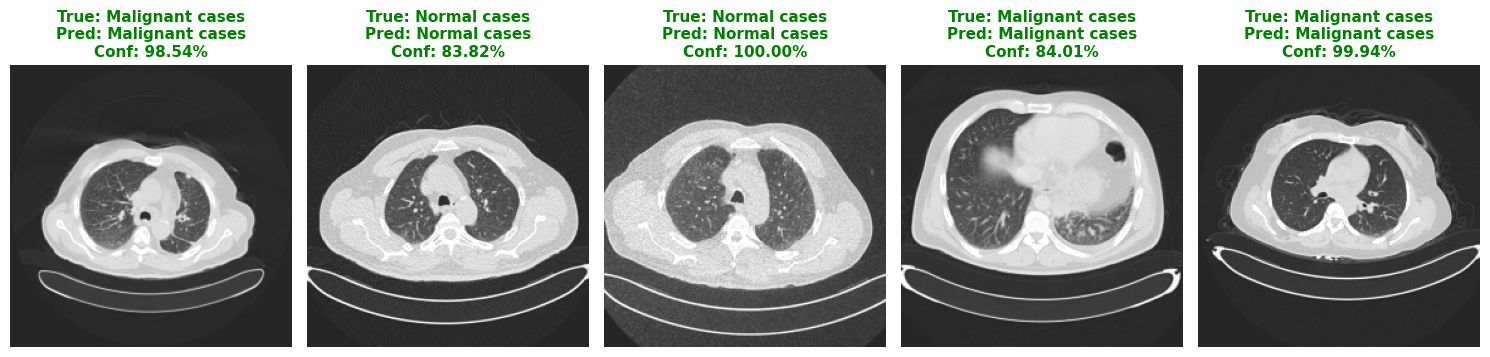

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import cv2

print("="*60)
print("VERIFIKASI AKURASI 100%: PENGECEKAN DATA LEAKAGE (KONTEN GAMBAR)")
print("="*60)

# Fungsi untuk membaca ulang gambar dari path dan meremote hash yang sesuai dengan preprocessing saat training
def get_image_hash_from_path(img_path):
    img = cv2.imread(img_path)
    if img is None: return None
    img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (224, 224))
    img = img.astype(np.float32) / 255.0
    return hashlib.md5(img.tobytes()).hexdigest()

train_hashes = {}  # hash -> list of file paths
test_hashes = {}   # hash -> list of file paths

# Membaca ulang dari folder untuk mendapatkan meta nama file
for category in categories:
    train_dir = os.path.join(dataset_base_path, 'train', category)
    test_dir = os.path.join(dataset_base_path, 'test', category)
    
    if os.path.exists(train_dir):
        for f in os.listdir(train_dir):
            if f.endswith('.jpg'):
                p = os.path.join(train_dir, f)
                h = get_image_hash_from_path(p)
                if h:
                    if h not in train_hashes: train_hashes[h] = []
                    train_hashes[h].append(f"Train/{category}/{f}")
                    
    if os.path.exists(test_dir):
        for f in os.listdir(test_dir):
            if f.endswith('.jpg'):
                p = os.path.join(test_dir, f)
                h = get_image_hash_from_path(p)
                if h:
                    if h not in test_hashes: test_hashes[h] = []
                    test_hashes[h].append(f"Test/{category}/{f}")

overlap_hashes = set(train_hashes.keys()).intersection(set(test_hashes.keys()))

print(f"Total gambar valid (Train) : {sum(len(v) for v in train_hashes.values())}")
print(f"Total gambar valid (Test)  : {sum(len(v) for v in test_hashes.values())}")
print(f"Jumlah gambar duplikat     : {len(overlap_hashes)}")

if len(overlap_hashes) > 0:
    print("\n[PERINGATAN] Terdapat kebocoran data berdasarkan isi pixel gambar!")
    print("Berikut adalah beberapa file yang identik (Hanya menampilkan maks 15 agar tidak terlalu panjang):\n")
    
    count = 0
    for h in overlap_hashes:
        if count >= 15:
            print("... dan seterusnya")
            break
        train_files_str = ", ".join(train_hashes[h])
        test_files_str = ", ".join(test_hashes[h])
        print(f"  • {train_files_str}  \n    <== IDENTIK DENGAN ==> \n    {test_files_str}\n")
        count += 1
else:
    print("\n[AMAN] Tidak ada gambar yang persis sama antara Train dan Test. Split data sudah bersih.")

print("\n" + "="*60)
print("VERIFIKASI AKURASI 100%: VISUALISASI PREDIKSI (CONFIDENCE)")
print("="*60)

# Membongkar kembali data hasil evaluasi sebelumnya untuk mendapatkan probabilitas
y_true, _, y_pred_pruned, _, y_proba_pruned = eval_data

# Mengambil 5 gambar acak dari data testing
num_samples = 5
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(15, 4))
for i, idx in enumerate(random_indices):
    img = X_test[idx]
    true_label = categories[y_true[idx]]
    pred_label = categories[y_pred_pruned[idx]]
    
    # Skor keyakinan terbesar (probabilitas)
    confidence = np.max(y_proba_pruned[idx]) * 100
    
    # Setup warna jika benar/salah
    color = 'green' if true_label == pred_label else 'red'
    
    plt.subplot(1, num_samples, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}%", 
              color=color, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()